# 🌐 Eksperimen 02: Clustering Ketahanan Fasilitas Kesehatan Jawa Timur
**Mata Kuliah**: Proyek Analitika Data — Sains Data Terapan (PENS 2026)  
**Platform**: Cura (HealthTrust Platform)  
**Role**: Machine Learning Engineer  

---

### 📌 Tujuan Eksperimen:
1. **Segmentasi Geospasial Berbasis Ketahanan Faskes**: Mengelompokkan 38 Kabupaten/Kota di Jawa Timur berdasarkan kapasitas tempat tidur WHO, densitas tenaga medis, beban morbiditas, dan kerentanan KIA/stunting.
2. **Komparasi 3 Algoritma Unsupervised Learning**:
   - **K-Means Clustering** (Penentuan $k$ optimal via Elbow Method & Silhouette Score)
   - **Agglomerative Hierarchical Clustering** (Ward's Linkage & Dendrogram)
   - **DBSCAN** (Analisis kepadatan dan deteksi anomali/outlier)
3. **Reduksi Dimensi & Visualisasi Spasial 2D (PCA)**: Memvisualisasikan sebaran klaster wilayah pada ruang berdimensi rendah.
4. **Profiling & Rekomendasi Kebijakan Regional**: Menyusun profil klaster (Tier 1: Mandiri, Tier 2: Berkembang, Tier 3: Rentan) sebagai dasar navigasi kebijakan Dinkes & Bappeda.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print("Library clustering & visualisasi berhasil dimuat!")

Library clustering & visualisasi berhasil dimuat!


## 1. Memuat Dataset & Penyiapan Fitur Analitik
Kita memuat skor indeks kesehatan dan fitur kapasitas dari `regional_health_index_scores.csv` dan `ml_readiness_dataset.csv`.

In [2]:
df_score = pd.read_csv('../data/regional_health_index_scores.csv')
df_ml = pd.read_csv('../../database/exports/ml_readiness_dataset.csv')

df = pd.merge(
    df_score, 
    df_ml[['kode_bps', 'total_rs', 'total_puskesmas', 'total_tt', 'kasus_rawat_inap_tahunan', 'proyeksi_penduduk_2026']], 
    on='kode_bps'
)

# Fitur untuk pemodelan
feature_cols = [
    'rasio_tt_proyeksi_2026',
    'rasio_dokter_per_1000',
    'prevalensi_stunting',
    'aki',
    'pilar_fasilitas',
    'pilar_nakes',
    'pilar_kia',
    'skor_kesehatan'
]

X = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data siap: {X_scaled.shape[0]} Wilayah x {X_scaled.shape[1]} Fitur")
df[['nama_wilayah'] + feature_cols].head(5)

Data siap: 38 Wilayah x 8 Fitur


,nama_wilayah,rasio_tt_proyeksi_2026,rasio_dokter_per_1000,prevalensi_stunting,aki,pilar_fasilitas,pilar_nakes,pilar_kia,skor_kesehatan
0,Kabupaten Pacitan,0.59,0.172,13.34,107.1,46.96,58.31,60.29,55.05
1,Kabupaten Ponorogo,1.26,0.150,19.80,97.2,54.62,47.43,44.03,50.36
2,Kabupaten Trenggalek,0.93,0.130,16.31,87.2,40.83,28.67,60.23,45.55
3,Kabupaten Tulungagung,1.91,0.143,12.55,81.4,57.76,34.13,75.49,44.98
4,Kabupaten Blitar,0.75,0.212,12.86,101.7,20.31,65.94,57.01,46.50


## 2. Penentuan Jumlah Klaster Optimal ($k$)
Kita mengevaluasi nilai $k = 2$ hingga $k = 7$ menggunakan **Elbow Method (Inertia SSE)** dan **Silhouette Score**.

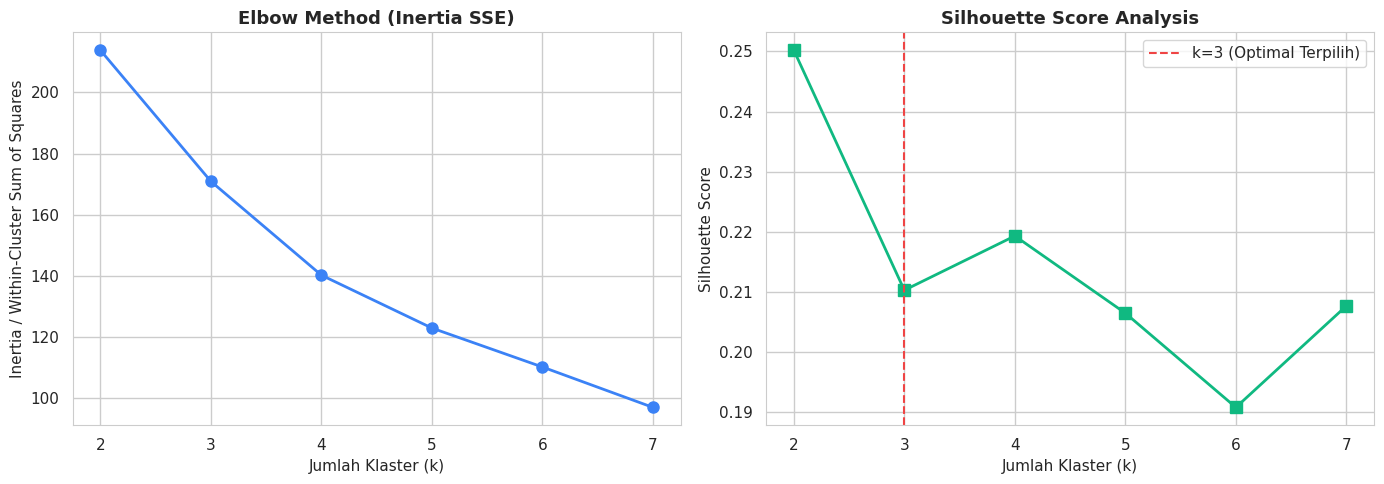

In [3]:
inertias = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax1[0].plot(k_range, inertias, marker='o', color='#3B82F6', linewidth=2, markersize=8)
ax1[0].set_title('Elbow Method (Inertia SSE)', fontsize=13, fontweight='bold')
ax1[0].set_xlabel('Jumlah Klaster (k)', fontsize=11)
ax1[0].set_ylabel('Inertia / Within-Cluster Sum of Squares', fontsize=11)

# Silhouette Plot
ax1[1].plot(k_range, sil_scores, marker='s', color='#10B981', linewidth=2, markersize=8)
ax1[1].axvline(3, color='#EF4444', linestyle='--', label='k=3 (Optimal Terpilih)')
ax1[1].set_title('Silhouette Score Analysis', fontsize=13, fontweight='bold')
ax1[1].set_xlabel('Jumlah Klaster (k)', fontsize=11)
ax1[1].set_ylabel('Silhouette Score', fontsize=11)
ax1[1].legend()

plt.tight_layout()
plt.show()

## 3. Agglomerative Hierarchical Clustering (Dendrogram)
Dendrogram menampilkan struktur taksonomi pohon hubungan kemiripan faskes antar wilayah Jawa Timur.

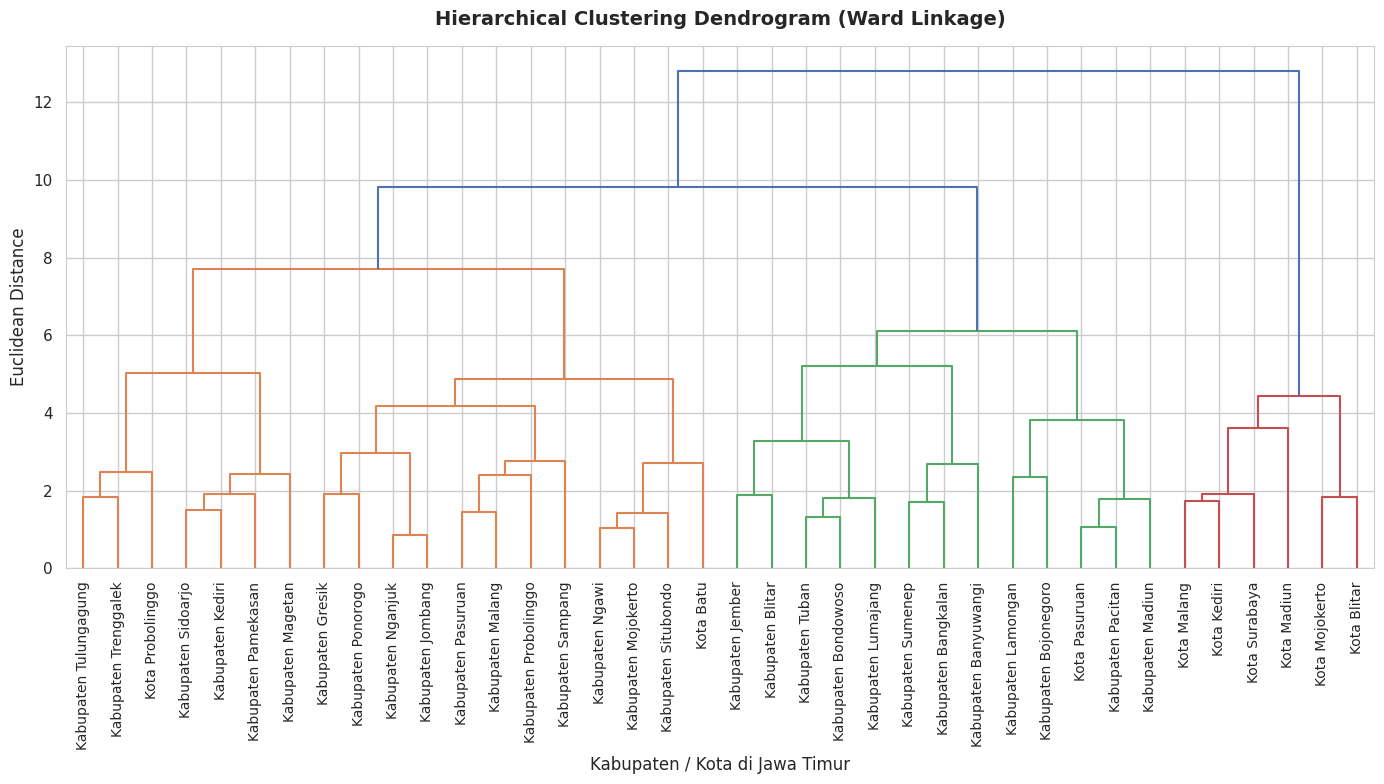

In [4]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linked,
    orientation='top',
    labels=df['nama_wilayah'].values,
    distance_sort='descending',
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kabupaten / Kota di Jawa Timur', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Visualisasi Proyeksi 2D PCA & Segmentasi Klaster
Reduksi dimensi ke 2 Principal Components untuk memetakan klaster wilayah secara intuitif.

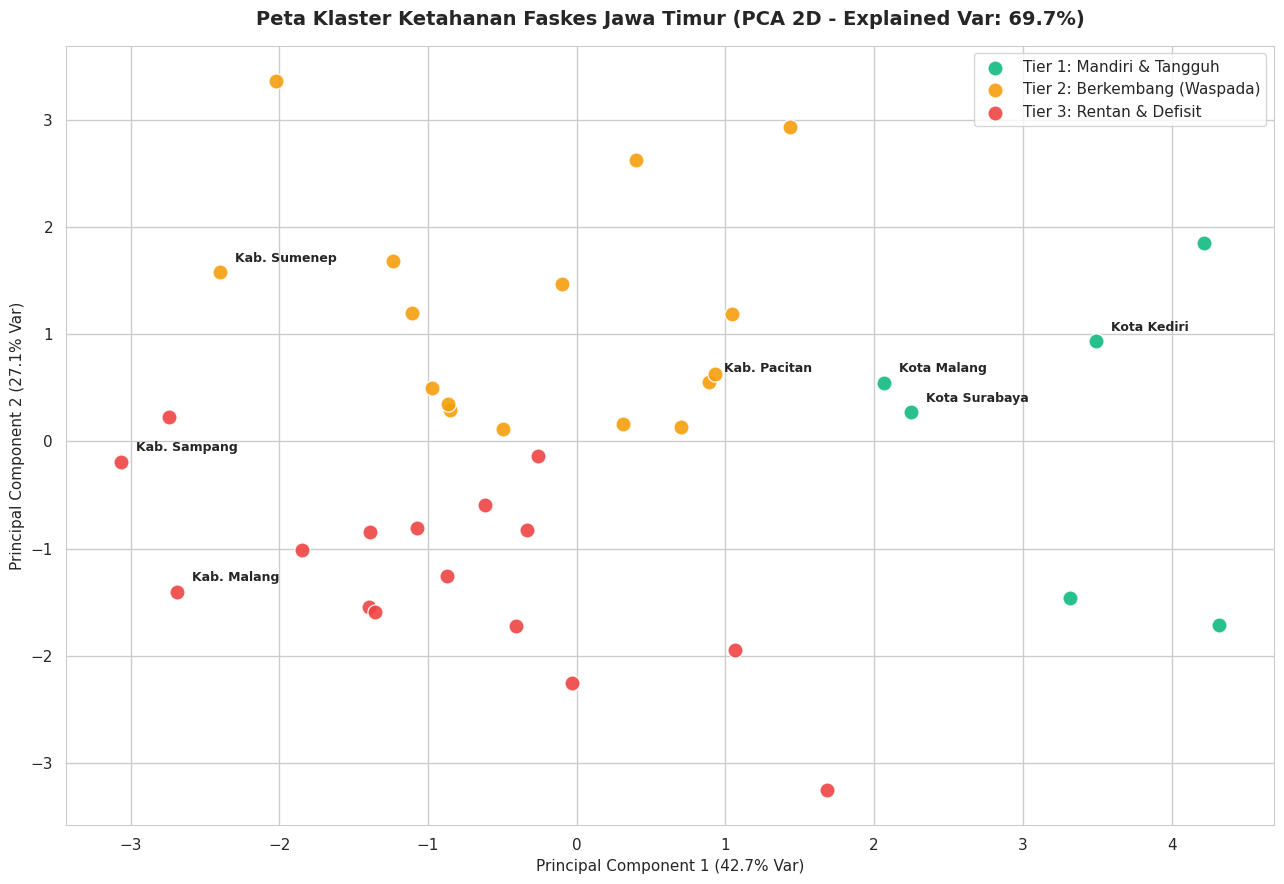

In [5]:
# Jalankan K-Means k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=25)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Proyeksi PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# Mapping nama & warna klaster
cluster_means = df.groupby('cluster_kmeans')['skor_kesehatan'].mean()
sorted_k = cluster_means.sort_values(ascending=False).index.tolist()

tier_map = {
    sorted_k[0]: ("Tier 1: Mandiri & Tangguh", "#10B981"),
    sorted_k[1]: ("Tier 2: Berkembang (Waspada)", "#F59E0B"),
    sorted_k[2]: ("Tier 3: Rentan & Defisit", "#EF4444")
}

df['cluster_tier'] = df['cluster_kmeans'].map(lambda x: tier_map[x][0])
df['cluster_color'] = df['cluster_kmeans'].map(lambda x: tier_map[x][1])

plt.figure(figsize=(13, 9))
for tier_name, color in [("Tier 1: Mandiri & Tangguh", "#10B981"), ("Tier 2: Berkembang (Waspada)", "#F59E0B"), ("Tier 3: Rentan & Defisit", "#EF4444")]:
    sub = df[df['cluster_tier'] == tier_name]
    plt.scatter(sub['pca_1'], sub['pca_2'], color=color, label=tier_name, s=120, edgecolors='white', alpha=0.9)

# Anotasi teks beberapa kota/kabupaten representatif
sample_labels = ['Kota Surabaya', 'Kota Kediri', 'Kabupaten Pacitan', 'Kabupaten Sumenep', 'Kabupaten Malang', 'Kabupaten Sampang', 'Kota Malang']
for _, row in df.iterrows():
    if row['nama_wilayah'] in sample_labels:
        plt.text(row['pca_1'] + 0.1, row['pca_2'] + 0.1, row['nama_wilayah'].replace('Kabupaten ', 'Kab. ').replace('Kota ', 'Kota '), fontsize=9, fontweight='semibold')

plt.title(f'Peta Klaster Ketahanan Faskes Jawa Timur (PCA 2D - Explained Var: {pca.explained_variance_ratio_.sum():.1%})', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Var)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Var)', fontsize=11)
plt.legend(frameon=True, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Radar Chart Perbandingan Karakteristik Antar Klaster
Visualisasi spider/radar chart menunjukkan kekuatan dan kelemahan masing-masing klaster pada 5 pilar kesehatan.

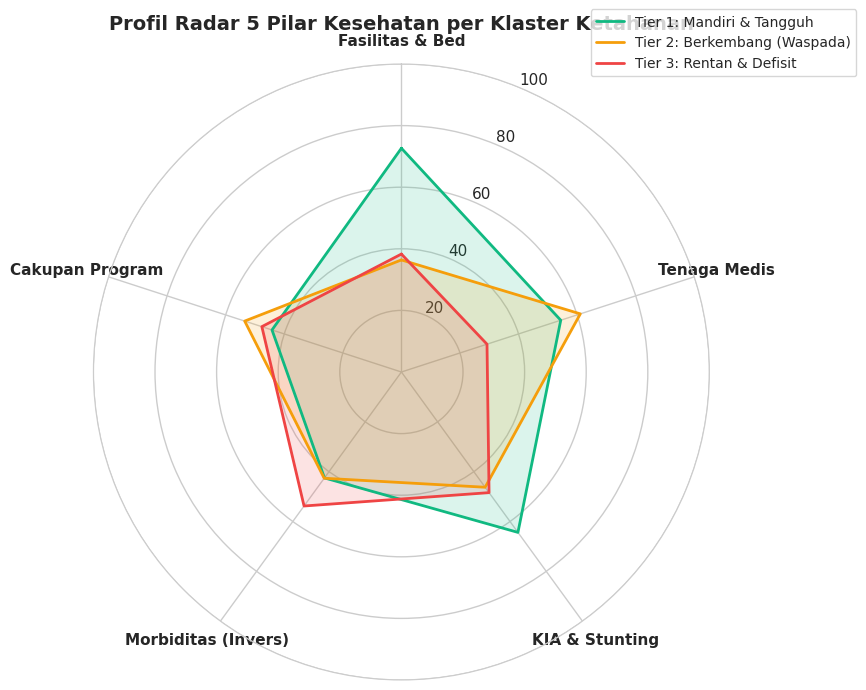

In [6]:
pilars = ['pilar_fasilitas', 'pilar_nakes', 'pilar_kia', 'pilar_morbiditas', 'pilar_program']
pilar_labels = ['Fasilitas & Bed', 'Tenaga Medis', 'KIA & Stunting', 'Morbiditas (Invers)', 'Cakupan Program']

cluster_summary = df.groupby('cluster_tier')[pilars].mean()

# Radar Chart
num_vars = len(pilars)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = {'Tier 1: Mandiri & Tangguh': '#10B981', 'Tier 2: Berkembang (Waspada)': '#F59E0B', 'Tier 3: Rentan & Defisit': '#EF4444'}

for tier, col_val in colors.items():
    values = cluster_summary.loc[tier].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=col_val, linewidth=2, label=tier)
    ax.fill(angles, values, color=col_val, alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(pilar_labels, fontsize=11, fontweight='semibold')
ax.set_ylim(0, 100)
plt.title('Profil Radar 5 Pilar Kesehatan per Klaster Ketahanan', size=14, fontweight='bold', pad=25)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)
plt.show()

## 6. Tabel Profiling & Rekomendasi Kebijakan
Ringkasan karakteristik dan jumlah anggota per klaster untuk konsumsi laporan manajerial.

In [7]:
summary_table = df.groupby('cluster_tier').agg(
    Jumlah_Wilayah=('kode_bps', 'count'),
    Rata_Skor_Kesehatan=('skor_kesehatan', 'mean'),
    Rasio_Bed_Proyeksi=('rasio_tt_proyeksi_2026', 'mean'),
    Rasio_Dokter_1k=('rasio_dokter_per_1000', 'mean'),
    Prevalensi_Stunting=('prevalensi_stunting', 'mean'),
    AKI_Rata=('aki', 'mean')
).round(2).reset_index()

summary_table

,cluster_tier,Jumlah_Wilayah,Rata_Skor_Kesehatan,Rasio_Bed_Proyeksi,Rasio_Dokter_1k,Prevalensi_Stunting,AKI_Rata
0,Tier 1: Mandiri & Tangguh,6,58.14,5.47,0.17,10.89,102.35
1,Tier 2: Berkembang (Waspada),16,47.30,1.13,0.19,16.28,102.56
2,Tier 3: Rentan & Defisit,16,42.74,1.25,0.14,17.74,90.58
